# Modell-Inspektion
Vorhersagen verschiedener Runs auf ungefärbten Tiles vergleichen

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import os
from unet import Unet
import random

In [7]:
# ── Einstellungen ─────────────────────────────────────────────────
cwd        = Path.cwd().parent.parent
img_dir    = cwd / 'Projektpraktikum_Master/augmentation_testing/dat/val/img'
res_dir    = Path('res')

# Runs die verglichen werden sollen
runs = [
    "MaskedGauss",
    "gray"
    
]

n_tiles    = 6      # wie viele Tiles angezeigt werden
threshold  = 0.35    # Schwellwert für Binärmaske
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [8]:
# ── Modelle laden ─────────────────────────────────────────────────
models = {}
for run in runs:
    model_path = res_dir / run / 'last_model.pth'
    if not model_path.exists():
        print(f'⚠ {run}: last_model.pth nicht gefunden')
        continue
    state_dict = torch.load(model_path, map_location=device)

    state_dict = {
        k.replace("_orig_mod.", ""): v
        for k, v in state_dict.items()
    }
    m = Unet().to(device)
    m.load_state_dict(state_dict)
    m.eval()
    models[run] = m
    print(f'✓ {run} geladen')

print(f'\n{len(models)} Modelle geladen.')

✓ MaskedGauss geladen
✓ gray geladen

2 Modelle geladen.


In [13]:
# ── Tiles laden ───────────────────────────────────────────────────
valid_ext = ('.png', '.jpg', '.jpeg', '.tif', '.tiff')
# tile_paths = sorted([
#     p for p in img_dir.iterdir()
#     if p.suffix.lower() in valid_ext
# ])[:n_tiles]
all_tiles = sorted([
    p for p in img_dir.iterdir()
    if p.suffix.lower() in valid_ext
])
tile_paths = random.sample(all_tiles, n_tiles)
mask_paths = [
    Path(str(p).replace("/img/", "/mask/"))
    for p in tile_paths
]
print(f'{len(tile_paths)} Tiles gefunden.')

def load_tile(path):
    img = Image.open(path).convert('L')
    t   = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.0
    return t

def predict(model, tile):
    with torch.no_grad():
        inp = tile.unsqueeze(0).to(device)
        out = model(inp)
        prob = torch.sigmoid(out).squeeze().cpu().numpy()
    return prob

6 Tiles gefunden.


In [14]:
tile_paths, mask_paths

([PosixPath('/run/media/tim/Volume/pythonReps/Projektpraktikum_Master/augmentation_testing/dat/val/img/256_4096.png'),
  PosixPath('/run/media/tim/Volume/pythonReps/Projektpraktikum_Master/augmentation_testing/dat/val/img/256_6144.png'),
  PosixPath('/run/media/tim/Volume/pythonReps/Projektpraktikum_Master/augmentation_testing/dat/val/img/256_4352.png'),
  PosixPath('/run/media/tim/Volume/pythonReps/Projektpraktikum_Master/augmentation_testing/dat/val/img/256_1280.png'),
  PosixPath('/run/media/tim/Volume/pythonReps/Projektpraktikum_Master/augmentation_testing/dat/val/img/0_5632.png'),
  PosixPath('/run/media/tim/Volume/pythonReps/Projektpraktikum_Master/augmentation_testing/dat/val/img/256_2304.png')],
 [PosixPath('/run/media/tim/Volume/pythonReps/Projektpraktikum_Master/augmentation_testing/dat/val/mask/256_4096.png'),
  PosixPath('/run/media/tim/Volume/pythonReps/Projektpraktikum_Master/augmentation_testing/dat/val/mask/256_6144.png'),
  PosixPath('/run/media/tim/Volume/pythonReps/P

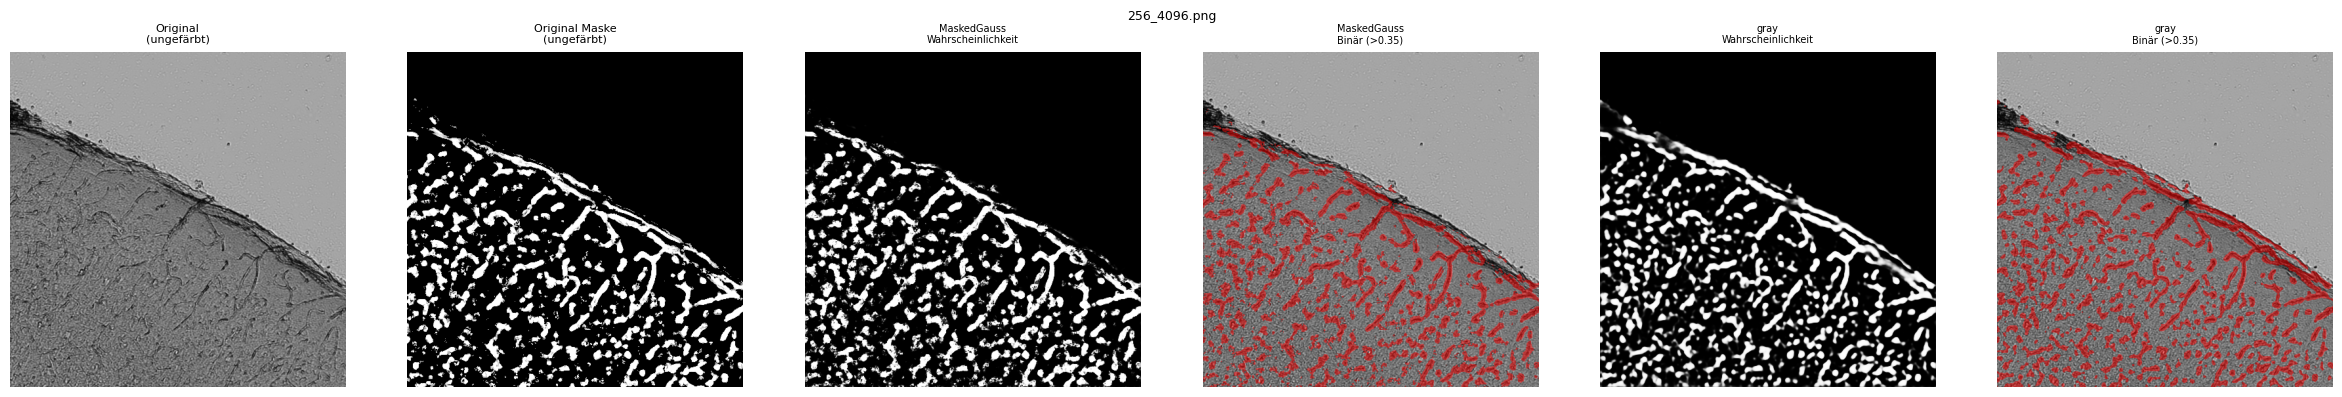

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 177 but got size 176 for tensor number 1 in the list.

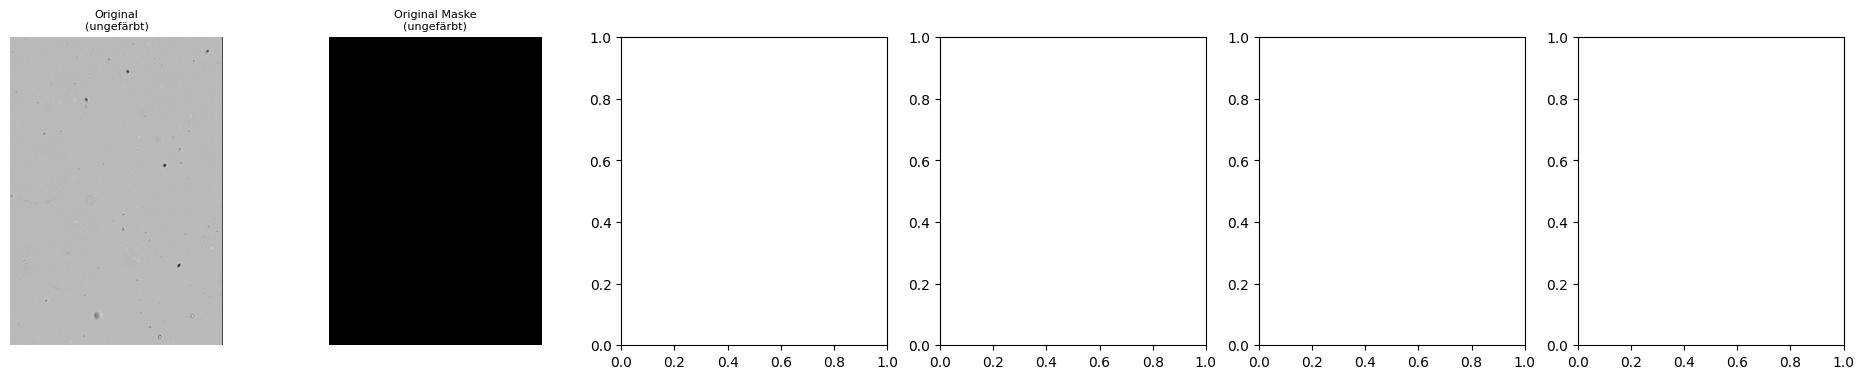

In [15]:
# ── Visualisierung ────────────────────────────────────────────────
n_cols = 2 + len(models) * 2  # Bild + Soll-Mask + (prob + binary) pro Modell

for tile_path, mask_path in zip(tile_paths, mask_paths):
    tile = load_tile(tile_path)
    mask = load_tile(mask_path)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

    # Original
    axes[0].imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Original\n(ungefärbt)', fontsize=8)
    axes[0].axis('off')
    
    axes[1].imshow(mask.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Original Maske\n(ungefärbt)', fontsize=8)
    axes[1].axis('off')
    # Vorhersagen
    for i, (run, model) in enumerate(models.items()):
        prob   = predict(model, tile)
        binary = (prob > threshold).astype(float)

        ax_prob   = axes[2 + i * 2]
        ax_binary = axes[3 + i * 2]

        ax_prob.imshow(prob, cmap='gray', vmin=0, vmax=1)
        ax_prob.set_title(f'{run}\nWahrscheinlichkeit', fontsize=7)
        ax_prob.axis('off')

        ax_binary.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
        overlay = np.zeros((*binary.shape, 4))
        overlay[..., 0] = 1.0
        overlay[..., 3] = binary * 0.5
        ax_binary.imshow(overlay)
        ax_binary.set_title(f'{run}\nBinär (>{threshold})', fontsize=7)
        ax_binary.axis('off')

    plt.suptitle(tile_path.name, fontsize=9)
    plt.tight_layout()
    plt.show()

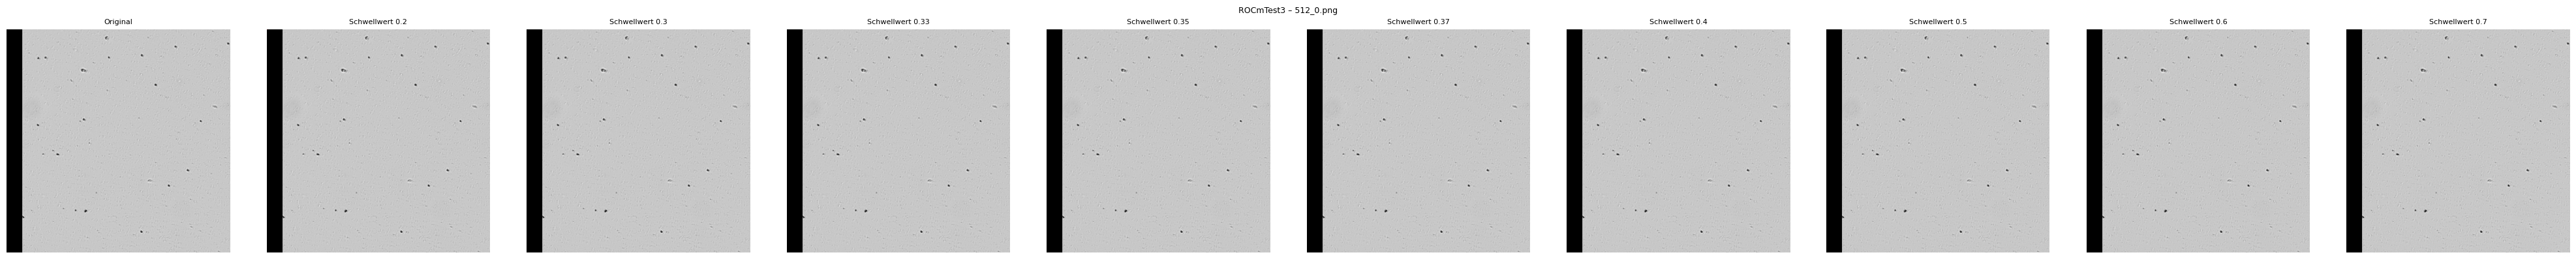

In [22]:
# ── Schwellwert interaktiv anpassen ──────────────────────────────
# Einzelnes Tile mit verschiedenen Schwellwerten anschauen
tile_idx   = 5   # welches Tile
run_name   = runs[0]  # welches Modell
thresholds = [0.2,0.3,0.33,0.35,0.37, 0.4, 0.5, 0.6, 0.7]

tile  = load_tile(tile_paths[tile_idx])
prob  = predict(models[run_name], tile)

fig, axes = plt.subplots(1, len(thresholds) + 1, figsize=(4*(len(thresholds)+1), 4))
axes[0].imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original', fontsize=8)
axes[0].axis('off')

for ax, t in zip(axes[1:], thresholds):
    binary = (prob > t).astype(float)
    ax.imshow(tile.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
    overlay = np.zeros((*binary.shape, 4))
    overlay[..., 0] = 1.0
    overlay[..., 3] = binary * 0.5
    ax.imshow(overlay)
    ax.set_title(f'Schwellwert {t}', fontsize=8)
    ax.axis('off')

plt.suptitle(f'{run_name} – {tile_paths[tile_idx].name}', fontsize=9)
plt.tight_layout()
plt.show()